Loaded 10 trajectories

── Steady-state statistics (t = 180–200) ──────────────────
Mean per trajectory:  [13.21  9.76 25.07 24.29 14.1  25.7  25.12 15.27 21.12 11.38]
Overall mean:         18.50  (theoretical: 16.67)
Overall std:          6.03
Overall variance:     36.42
Noise (CV = std/mean):0.33

Plot saved: stochastic_analysis.png


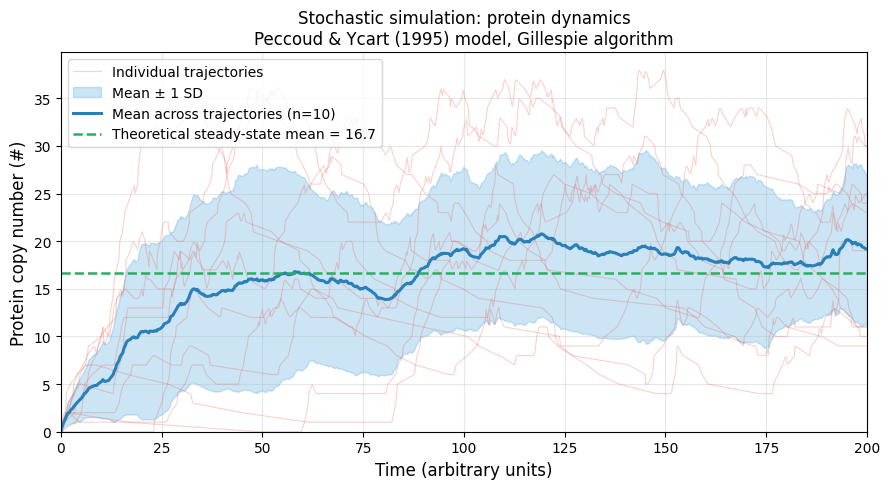

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#model parameters
lambda_ = 0.05   #gene activation rate (OFF -> ON)
mu      = 0.10   #gene deactivation rate (ON -> OFF)
nu      = 1.0    #protein synthesis rate
delta   = 0.02   #protein degradation rate

#analytical steady-state mean: E = lambda * nu / ((lambda + mu) * delta)
theoretical_mean = (lambda_ * nu) / ((lambda_ + mu) * delta)

#load data
#COPASI exports all trajectories in a single file
#trajectories are separated by rows of NaN values
#each row: Time  G_on.ParticleNumber  G_off.ParticleNumber  Prot.ParticleNumber

trajectories = []
current = []
file_path = "/Users/alaksandradynko/Downloads/MCBS/data_stocastic10traj.txt"
with open(file_path) as f:
    for line in f:
        line = line.strip()
        if line.startswith("#") or line == "":
            continue
        vals = line.split("\t")
        try:
            row = [float(v) for v in vals[:4]]
            if np.isnan(row[0]):  #NaN row marks end of one trajectory
                if current:
                    trajectories.append(np.array(current))
                    current = []
            else:
                current.append(row)
        except ValueError:
            pass

if current: 
    trajectories.append(np.array(current))

print(f"Loaded {len(trajectories)} trajectories")

# =============================================================================
# 3. INTERPOLATE ONTO A COMMON TIME GRID
# =============================================================================
# Gillespie algorithm produces events at irregular time points.
# We interpolate each trajectory onto a uniform grid to enable
# pointwise averaging across trajectories.

t_grid   = np.linspace(0, 200, 1000)
prot_all = []

for i, traj in enumerate(trajectories):
    t    = traj[:, 0]   # time
    prot = traj[:, 3]   # Prot.ParticleNumber
    # np.interp performs linear interpolation; for integer particle numbers
    # this approximates the piecewise-constant Gillespie trajectory
    prot_interp = np.interp(t_grid, t, prot)
    prot_all.append(prot_interp)

prot_all = np.array(prot_all)          # shape: (n_trajectories, n_timepoints)

# Compute mean and standard deviation at each time point
mean_prot = prot_all.mean(axis=0)
std_prot  = prot_all.std(axis=0)

# =============================================================================
# 4. STEADY-STATE STATISTICS
# =============================================================================
# Use the last 10% of the simulation (t = 180-200) as the steady-state window
steady_state = prot_all[:, -100:]      # last 100 time points

ss_mean_per_traj = steady_state.mean(axis=1)
ss_overall_mean  = ss_mean_per_traj.mean()
ss_overall_std   = ss_mean_per_traj.std()
ss_overall_var   = ss_mean_per_traj.var()

print(f"\n── Steady-state statistics (t = 180–200) ──────────────────")
print(f"Mean per trajectory:  {np.round(ss_mean_per_traj, 2)}")
print(f"Overall mean:         {ss_overall_mean:.2f}  "
      f"(theoretical: {theoretical_mean:.2f})")
print(f"Overall std:          {ss_overall_std:.2f}")
print(f"Overall variance:     {ss_overall_var:.2f}")
print(f"Noise (CV = std/mean):{ss_overall_std / ss_overall_mean:.2f}")

# =============================================================================
# 5. PLOT
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))

# Individual trajectories (faint background)
for i, prot in enumerate(prot_all):
    ax.plot(t_grid, prot,
            color="#e74c3c", alpha=0.25, linewidth=0.8,
            label="Individual trajectories" if i == 0 else "")

# Shaded mean ± 1 SD band
ax.fill_between(t_grid,
                mean_prot - std_prot,
                mean_prot + std_prot,
                color="#3498db", alpha=0.25,
                label="Mean ± 1 SD")

# Mean line
ax.plot(t_grid, mean_prot,
        color="#2980b9", linewidth=2.2,
        label=f"Mean across trajectories (n={len(trajectories)})")

# Theoretical steady-state prediction
ax.axhline(theoretical_mean,
           color="#27ae60", linewidth=1.8, linestyle="--",
           label=f"Theoretical steady-state mean = {theoretical_mean:.1f}")

ax.set_xlabel("Time (arbitrary units)", fontsize=12)
ax.set_ylabel("Protein copy number (#)", fontsize=12)
ax.set_title("Stochastic simulation: protein dynamics\n"
             "Peccoud & Ycart (1995) model, Gillespie algorithm",
             fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(0, 200)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("stochastic_analysis.png", dpi=150)
print("\nPlot saved: stochastic_analysis.png")